In [1]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader,random_split

from Tools.model_tools import load_configs, add_config
from Tools.data_utils import SimulationData,generate_input_filename
from Encoder import*

In [2]:
tau = 15
embedding_dim = 20
r = 10
alpha = 0
beta = 0
simulation_name= generate_input_filename(tau, embedding_dim, r, alpha, beta)
model_name = "Prova"      
scheduler_name = "ReduceLROnPlateau"
print(simulation_name)

delay15dim20,10_noise0,0


In [3]:
# Percorso del database
model_database_path = "encoderDatabase.json"

# Carica tutte le configurazioni disponibili
all_configs = load_configs(model_database_path)

print(model_name)

Prova


In [4]:
# Se vuoi creare una nuova configurazione

layer_dims = [r, 7, 5]  # Match legendre basis with shape of input
latent_dim = layer_dims[-1]

new_config = {
    "layer_dims" :layer_dims,
    "latent_dim": latent_dim,
    "beta_method": "sigmoid", #constant, sigmoid, linear, linear_decay, exponential_decay
    "beta_value": 0.01, # Valore di beta
    "kl_annealing_epochs":  700, # Epoche di warmup
    "decay_start": 100, # Epoch di inizio del decadimento
    "decay_epoch": 50, # Durata del decadimento
    "early_stopping": {"patience": 10, "delta": -1}, # Early stopping -1 per disattivare
    "dataset": simulation_name,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.01,
    "scheduler": {
        "type": scheduler_name,  # Scheduler alternativo
        "params": {
            "mode": "min",  # Monitorare la perdita minima
            "factor": 0.5,  # Fattore di riduzione
            "patience": 15,  # Epoche prima di ridurre
            "min_lr": 0.0001,  # Limite inferiore
        }
    }
}

epochs = 900

# Aggiungi la nuova configurazione al database
#add_config(new_config, model_name, model_database_path)
print(all_configs)

{'Prova': {'layer_dims': [10, 7, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,10_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}}


In [5]:
# Carica una configurazione esistente
selected_model = new_config

# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, r=r, alpha=alpha, beta=beta, input_path="Simulation data"
)

# Seleziona gli embedding dal SimulationData
y1_reduced_data = simulation.projected_H1



# Verifica che gli embedding siano stati generati correttamente
if y1_reduced_data is None:
    raise ValueError("Uno o più embedding non sono stati generati correttamente!")

In [6]:
# Crea il dataset
embedded_dataset = EmbeddedDataset(y1_reduced_data)
print("embedded_dataset shape:", embedded_dataset.data.shape)
print("embedded_dataset n. samples:", len(embedded_dataset.data))

# Suddivisione del dataset
total_size = len(embedded_dataset)
train_size = int(0.60 * total_size)  # 60% per il training
val_size = total_size - train_size   # 40% per la validazione

# Suddivisione del dataset senza random split
train_data = torch.utils.data.Subset(embedded_dataset, range(train_size))
val_data = torch.utils.data.Subset(embedded_dataset, range(train_size, total_size))

# Stampa delle dimensioni
print(f"SHAPE dei campioni di Training: {train_data.dataset.data.shape}")
print(f"SHAPE dei campioni di Validazione: {val_data.dataset.data.shape}")

# Prepara il DataLoader
batch_size = selected_model["batch_size"]
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Debug del batch
for batch in train_loader:
    x, y = batch  # Decomponi input e output
    x = x.float()
    y = y.float()
    print("Shape of input:", x.shape)
    break



embedded_dataset shape: torch.Size([648, 10])
embedded_dataset n. samples: 648
SHAPE dei campioni di Training: torch.Size([648, 10])
SHAPE dei campioni di Validazione: torch.Size([648, 10])
Shape of input: torch.Size([32, 10])


Epoch [1/900], Rec Loss: 1.1415, KLD Loss: 0.2850, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 1.1415, lr = 0.010000
Epoch [2/900], Rec Loss: 1.0729, KLD Loss: 0.9444, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 1.0729, lr = 0.010000
Epoch [3/900], Rec Loss: 0.9732, KLD Loss: 1.9066, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.9732, lr = 0.010000
Epoch [4/900], Rec Loss: 0.7383, KLD Loss: 5.1543, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.7383, lr = 0.010000
Epoch [5/900], Rec Loss: 0.5976, KLD Loss: 5.9979, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.5976, lr = 0.010000
Epoch [6/900], Rec Loss: 0.5324, KLD Loss: 9.1173, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.5324, lr = 0.010000
Epoch [7/900], Rec Loss: 0.4985, KLD Loss: 13.3271, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.4985, lr = 0.010000
Epoch [8/900], Rec Loss: 0.4785, KLD Loss: 15.6333, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.4785, lr = 0.010000
Epoch [9/900], Rec Loss: 0.4382, KLD Loss: 17.7988, Beta: 0.00

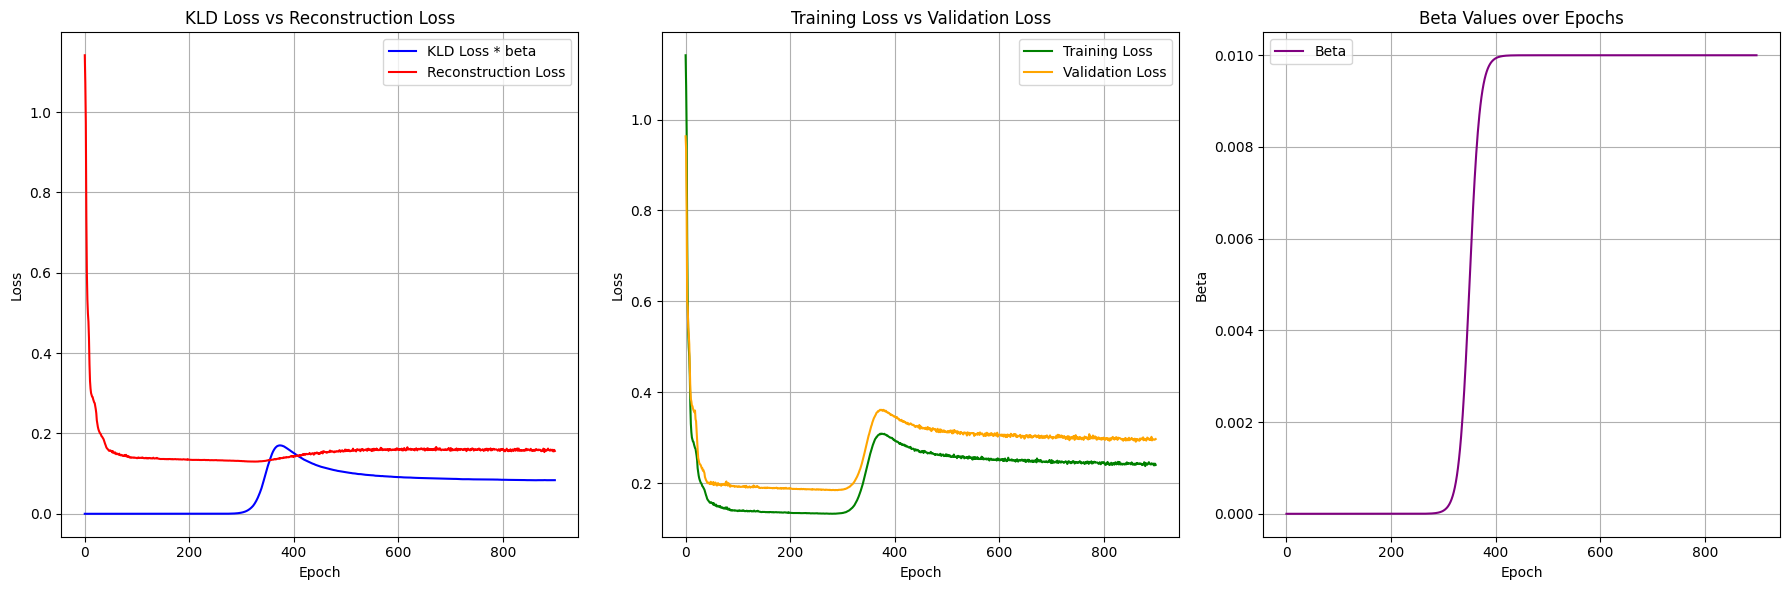

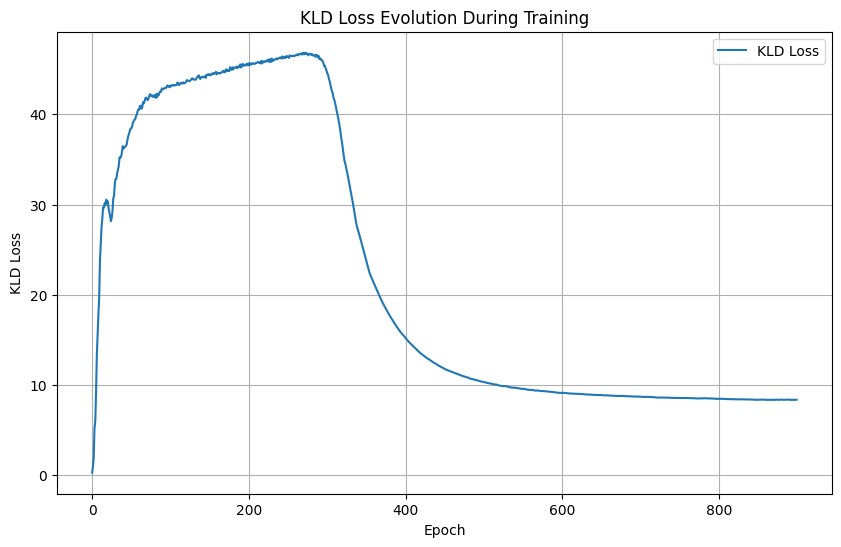

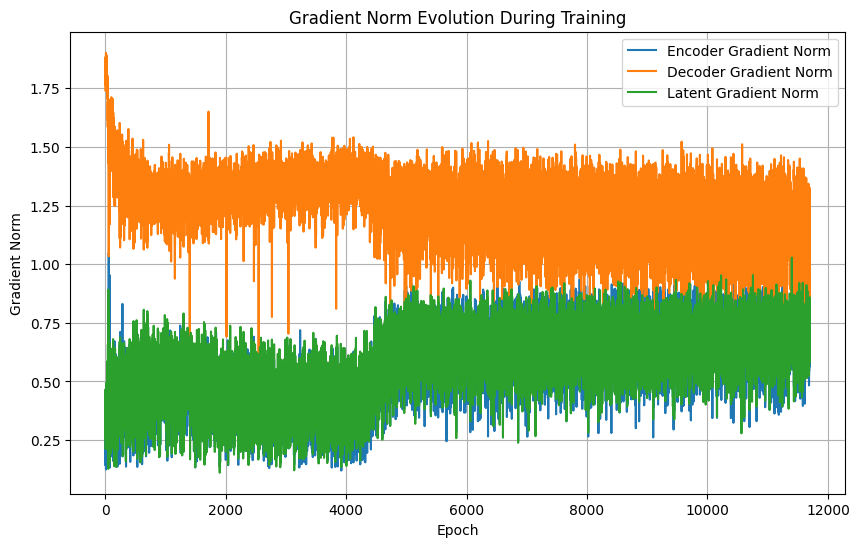

In [7]:
# Creazione del Modello

encoder = Encoder(layer_dims)
decoder = Decoder(layer_dims)

vae_model = VAE(encoder, decoder)

#for name, param in vae_model.named_parameters():
#    print(name, param.shape)

# Configura ottimizzatore e scheduler dai parametri del modello
optimizer = optim.Adam(vae_model.parameters(), lr=selected_model["learning_rate"])
scheduler_config = selected_model.get("scheduler")
scheduler = get_scheduler(optimizer, scheduler_config)

# Esecuzione del training
train_losses, val_losses, recon_losses, kld_losses,effective_kld_losses, beta_values, stopped_epoch, gradient_history, lr_evolution = trainEncoder(
    epochs=epochs,
    train_loader=train_loader,
    val_loader=val_loader,  # Aggiungi se hai un dataset di validazione
    model=vae_model,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_config=scheduler_config,
    kl_annealing_epochs=selected_model["kl_annealing_epochs"],
    decay_epoch=selected_model["decay_epoch"],
    decay_start=selected_model["decay_start"],
    beta_method=selected_model["beta_method"],
    beta_value=selected_model["beta_value"],
    early_stopping_params=selected_model["early_stopping"]
)


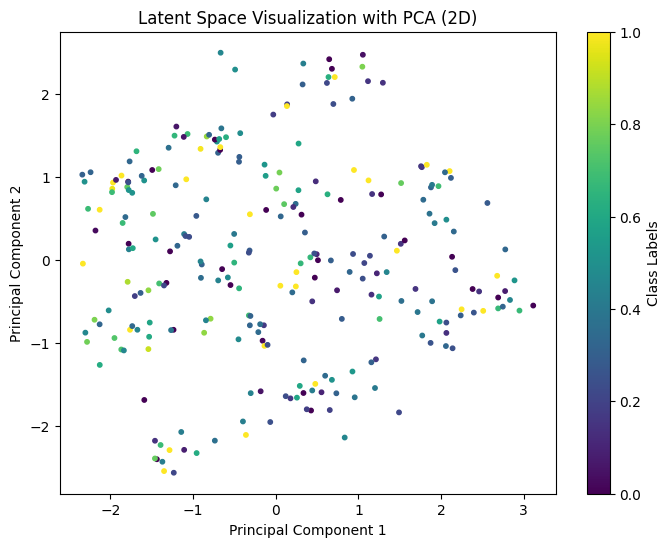

In [8]:
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

In [9]:
# Carica la configurazione creata nel Databse degli Encoder
all_configs = load_configs(model_database_path)

In [10]:
# Salva la configurazione nel database
add_config(new_config, model_name, model_database_path)
# Salva il modello
model_name += ".pth"

denormalizing_params = {
    "min_h1": simulation.min_h1,
    "max_h1": simulation.max_h1,
    "min_h2_1": simulation.min_h2_1,
    "max_h2_1": simulation.max_h2_1,
    "min_h2_2": simulation.min_h2_2,
    "max_h2_2": simulation.max_h2_2
}

#TODO: For analysis are needed: min max for denorm, Legendre Basis for reverse projection
# Neede also original Hankel matrix due to noise in reverse projection
save_encoder(
    encoder=encoder,
    decoder=decoder,
    optimizer=optimizer,
    train_data=train_data,
    val_data=val_data,  # Aggiungi se hai un dataset di validazione
    epoch=50,
    stopped_epoch=stopped_epoch,
    encoder_layers=layer_dims,
    decoder_layers=layer_dims,
    train_losses=train_losses,
    val_losses=val_losses,
    recon_losses=recon_losses,
    kld_losses=kld_losses,
    effective_kld_losses=effective_kld_losses,
    beta_values=beta_values,
    gradient_history=gradient_history,
    denormalizing_params= denormalizing_params,
    legendreBasis= simulation.P,
    H1= simulation.H1,
    H2_1= simulation.H2_1,
    H2_2= simulation.H2_2,
    output_folder="Encoder Models",
    model_name=model_name
)

Model Prova already exists in the database. Overwriting...
Model saved to Encoder Models/Prova.pth
